In [1]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 50.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gymnasium]/2 [gymnasium]


In [2]:
!pip install sb3-contrib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sb3-contrib] [sb3-contrib]


In [3]:
import sys
sys.path.append("/project_ghent/chronocooked")

In [4]:
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os

In [5]:
# from matplotlib.colors import ListedColormap

# from matplotlib.colors import BoundaryNorm

In [5]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [6]:
from tensorboard.backend.event_processing import event_accumulator

In [7]:
from singleagent.rl_environments.bisection_multi_oven import ChronoCookedBisectionMultiOven

In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy.stats import ttest_ind, shapiro, levene, ttest_1samp, f_oneway, ttest_rel, mannwhitneyu, wilcoxon

In [9]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

In [10]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [11]:
# map seed to each starting point
env = ChronoCookedBisectionMultiOven(max_timesteps=200)
seeds = {(int(ax),int(ay)): -1 for ax, ay in zip(np.where(env.reset(seed=0)[0][:,:,0] ==0)[0],np.where(env.reset(seed=0)[0][:,:,0] ==0)[1])}
for s in range(1,30,1):
    ax, ay = np.where(env.reset(seed=s)[0][:,:,1] ==1)
    if seeds[int(ax[0]),int(ay[0])] == -1:
        seeds[int(ax[0]),int(ay[0])] = s
seeds

oven duration selected for oven 0 6
oven duration selected for oven 1 12
oven duration selected for oven 0 12
oven duration selected for oven 1 6
oven duration selected for oven 0 6
oven duration selected for oven 1 6
oven duration selected for oven 0 6
oven duration selected for oven 1 6
oven duration selected for oven 0 6
oven duration selected for oven 1 6
oven duration selected for oven 0 12
oven duration selected for oven 1 12
oven duration selected for oven 0 6
oven duration selected for oven 1 12
oven duration selected for oven 0 6
oven duration selected for oven 1 12
oven duration selected for oven 0 12
oven duration selected for oven 1 6
oven duration selected for oven 0 6
oven duration selected for oven 1 12
oven duration selected for oven 0 6
oven duration selected for oven 1 12
oven duration selected for oven 0 6
oven duration selected for oven 1 6
oven duration selected for oven 0 12
oven duration selected for oven 1 12
oven duration selected for oven 0 12
oven duration se

{(1, 0): 14, (1, 1): 1, (1, 2): 7, (2, 0): 9, (2, 1): 5, (2, 2): 19, (3, 2): 2}

In [12]:
def plot_traj(obs_concat, act_concat, reward_concat, figsize = (10,5), n_rows = 2, cmap = 'viridis'):
    arr = np.array(obs_concat)  # (200, 5, 3)
    max_val = arr.max()
    
    cmap = plt.get_cmap("tab20", max_val + 1)
    norm = BoundaryNorm(np.arange(max_val + 2) - 0.5, cmap.N)
    
    colors = [
        "#000000",  # 0
        "#e41a1c",  # 1
        "#377eb8",  # 2
        "#4daf4a",  # 3
        "#984ea3",  # 4
        "#ff7f00",  # 5
        "#ffff33",  # 6
        "#a65628",  # 7
        "#f781bf",  # 8
        "#17becf",  # 9
        "#999999",  # 10
        "#8dd3c7",  # 11 
    ]
    
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(len(colors) + 1) - 0.5, len(colors))# plot_traj(observation_history125_2sync[anchor]['1-950000'][td][seed_i][0:50], action_history125_2sync[anchor]['1-950000'][td][seed_i][0:50], 
    
    n_cols = len(arr) // n_rows + 1# 40
    
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,10))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    for i, ax in enumerate(axes.flat):
        if i >= len(arr):
            break
        ax.imshow(arr[i], cmap = cmap,  norm=norm, interpolation="nearest", aspect="equal")
        # ax.text(0.5, -0.6, str(act_concat[i]), fontsize=12)
        # ax.text(0.2, 5.6, str(reward_concat[i]), fontsize=12)
        if reward_concat:
            ax.set_title(f"A:{act_concat[i]} R:{reward_concat[i]}", fontsize=9, fontdict={"color":"red"})
        else:
            ax.set_title(f"A:{act_concat[i]}", fontsize=9)
        # x = ax.set_xticks(x_ticks, [f"{int(l[0])} , {str(l[1])}, {str(l[2])} " for l in zip(act_concat, range(len(act_concat)), reward_concat)], rotation =90, ha='right', fontsize=10)
    
        ax.axis('off')  # hide axes for clarity
    
    plt.tight_layout()
    plt.show()

In [13]:
# utils
def get_eplen_across_training(tb_event_file, max_training_ts_env0):
    ea = event_accumulator.EventAccumulator(tb_event_file)
    ea.Reload()
    eplen = ea.Scalars("rollout/ep_len_mean") 
    eplen_dict = {a_kl.step:a_kl.value for a_kl in eplen if (a_kl.step % 20000 == 0) & (a_kl.step>max_training_ts_env0)}
    return eplen_dict

In [14]:
def get_min_ts_lastlevel(tb_event_file): # for the last level check if models learns task before max timesteps 
    # trainign timesteps needed for new anchor
    ea = event_accumulator.EventAccumulator(tb_event_file)
    ea.Reload()
    
    events = ea.Scalars("rollout/ep_rew_mean")
    
    steps = np.array([e.step for e in events])
    rewards = np.array([e.value for e in events])
    
    drop_fraction = 0.20  # 20%
    
    end_reward = rewards[-1]
    start_idx = 0
    
    if end_reward >=0.8: # get the first timestep with 20% performance increase 
        for i in range(len(rewards) - 2, -1, -1):
            if rewards[i] < (1 - drop_fraction) * end_reward:
                start_idx = i + 1
                break
    
    return steps[start_idx]

In [15]:
def get_cl_task_performance(lstm_size=125, ctrnn=False, max_ovens=3, asynchronous=True):
    
    delivery_counter_used_history = {}
    observation_history = {}
    action_history = {}
    reward_history = {}
    min_training_timesteps = {}
    models_history = {}
    
    short_durations=(4,)
    long_durations=(8,12,18)
    ent_coeff = 0
    timestep = 200
    g = 0.99    
    multioven_suffix = "async" if asynchronous else "sync"
    
    for short_duration in short_durations:
        for long_duration in long_durations:
            
            delivery_counter_used_history[f"{short_duration}-{long_duration}"] = {}
            observation_history[f"{short_duration}-{long_duration}"] = {}
            action_history[f"{short_duration}-{long_duration}"] = {}
            reward_history[f"{short_duration}-{long_duration}"] = {}
            min_training_timesteps[f"{short_duration}-{long_duration}"] = {}
            models_history[f"{short_duration}-{long_duration}"] = {}

            for n_ovens in range(1,max_ovens+1):
            
                for log in [1,2,3,4]:
    
                    models_folder = "/project_ghent/chronocooked/singleagent/train/bisection_multioven_cl_models2"
                    if lstm_size is None:
                        model_file = f"bisection_{max_ovens}oven_{multioven_suffix}_TD1{short_duration}_TD2{long_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs{log}/"
                    elif ctrnn:
                        model_file = f"bisection_{max_ovens}oven_{multioven_suffix}_TD1{short_duration}_TD2{long_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_ctrnn{lstm_size}_mlp64_gamma{g}_logs{log}/"
                    else:
                        model_file = f"bisection_{max_ovens}oven_{multioven_suffix}_TD1{short_duration}_TD2{long_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_logs{log}/"

                    try:
                        model_files = os.listdir(f"{models_folder}/{model_file}")
                        
                    except:
                        print("no such dir",f"{models_folder}/{model_file}" )
                        continue
                        
                    # get min timesteps needed for last level of curriculum leanring 
                    tb_event_file = [f"{models_folder}/{model_file}/{mod_file}" for mod_file in model_files if "env" not in mod_file][0]
                    min_ts_lastlevel = get_min_ts_lastlevel(tb_event_file)
                    print(min_ts_lastlevel)
                    
                    # get timesteps correspondign to transition to next level of curriculum learning 
                    max_training_ts_envi = max([int(mod_file.split("env")[1].split("_")[1])  if ("env" in mod_file) and (mod_file.split("env")[1].split("_")[0] == str(n_ovens-1)) else 0 for mod_file in model_files])

                    
                    if max_training_ts_envi == 0:
                        print("unsuucessful timign task", model_file, n_ovens)
                        continue 
                        
                    if (n_ovens == max_ovens) and (min_ts_lastlevel>1000):
                        min_training_timesteps[f"{short_duration}-{long_duration}"][log] =  min_training_timesteps[f"{short_duration}-{long_duration}"].get(log, []) + [min_ts_lastlevel]
                    else:
                        min_training_timesteps[f"{short_duration}-{long_duration}"][log] =  min_training_timesteps[f"{short_duration}-{long_duration}"].get(log, []) + [max_training_ts_envi]
                    
                    delivery_counter_used_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"] = {}
                    observation_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"] = {}
                    action_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"] = {}
                    reward_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"] = {}

                    env_test = ChronoCookedBisectionMultiOven(max_timesteps=timestep, short_duration=short_duration, long_duration=long_duration,
                                             asynchronous =asynchronous, n_ovens=n_ovens)

                    try:
                        if lstm_size is None:
                            model = PPO.load(f"{models_folder}/{model_file}/rl_model_env{n_ovens-1}_{max_training_ts_envi}_steps.zip", env=env_test)
                        else:
                            model = RecurrentPPO.load(f"{models_folder}/{model_file}/rl_model_env{n_ovens-1}_{max_training_ts_envi}_steps.zip", env=env_test)
                    except:
                        continue 

                    models_history[f"{short_duration}-{long_duration}"][log] =  models_history[f"{short_duration}-{long_duration}"].get(log, []) + [dict(model.policy.named_parameters())]
    
                    
                    for td in range(1,long_duration+5):
                        delivery_counter_used_td = []
                        td_observations = []
                        td_actions = []
                        td_rewards = []
                                        
                                            
    
                        env_test = ChronoCookedBisectionMultiOven( max_timesteps=timestep, short_duration=short_duration, long_duration=long_duration,
                                             asynchronous =asynchronous, n_ovens=n_ovens)
    

    
                        for seed in seeds.values():
                            obs, _ = env_test.reset(seed=seed, oven_durations=[td]*n_ovens)
                            visual_obs = np.sum(obs,axis=2)
                            obs_concat = [visual_obs]
                            act_concat = []
                            reward_concat = []
                            # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
                            rewards=0
                            states = None
                            
                            for i in range(timestep + 2):
                                # obs = obs + 300
                                action, states = model.predict(obs, state=states, deterministic=True) 
                                act_concat.append(action)
                                # print(visual_obs)
                                # print("action",action)
                                obs, reward, done, _ ,_= env_test.step(action)
                                visual_obs = np.sum(obs,axis=2)
                                obs_concat.append(visual_obs)
                            
                                # print("reward",reward)
                                # print("oven timer", env_test.oven_timer)
                                
                                rewards += reward
                                reward_concat.append(reward)
                                if done:
                                    reward_concat.append(reward)
                                    act_concat.append(0)
                                    # print(env_test.delivery_counter_used)
                                    delivery_counter_used_td.append(env_test.delivery_counter_used.copy())
                                    # print(delivery_counter_used_td)
                                    td_observations.append(obs_concat)
                                    td_actions.append(act_concat)
                                    td_rewards.append(reward_concat)
                                    # print(seed, rewards)
                                    # obs,_ = env_test.reset()
                            
                                    # print("short_duration", short_duration, "long_duration", long_duration, "rewards",rewards, "delivery counter", env_test.delivery_counter_used, i+1)
                                    break
                        delivery_counter_used_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"][td] = delivery_counter_used_td
                        observation_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"][td] = td_observations
                        action_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"][td] = td_actions
                        reward_history[f"{short_duration}-{long_duration}"][f"{log}-{max_training_ts_envi}"][td] = td_rewards
    return delivery_counter_used_history, min_training_timesteps, models_history, observation_history, action_history, reward_history


In [23]:
delivery_counter_used_history125_async, min_training_timesteps125_async, models_history125_async, observation_history125_async, action_history125_async, reward_history125_async = get_cl_task_performance(lstm_size=125, max_ovens=3, asynchronous=True)

1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_sharedlstm125_mlp64_gamma0.99_logs1/ 3
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_sharedlstm125_mlp64_gamma0.99_logs2/ 3
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVe

In [18]:
min_training_timesteps125_async

{'4-8': {1: [92000, 1750000],
  2: [63000, 1750000],
  3: [81000, 1411000, 1750000],
  4: [61000, 1750000]},
 '4-12': {1: [89000, 1750000],
  2: [152000, 1084000, 1750000],
  3: [77000, 1750000],
  4: [183000, 1486000, 1750000]},
 '4-18': {1: [89000, 677000, 1750000],
  2: [93000, 1009000, 1750000],
  3: [88000, 841000, 1750000],
  4: [99000, 497000, 1750000]}}

In [20]:
for k, v in models_history125_async.items():
    print(k)
    for k_1, v_1 in v.items():
        print(k_1,len(v_1))
        # print()

4-8
1 2
2 2
3 3
4 2
4-12
1 2
2 3
3 2
4 3
4-18
1 3
2 3
3 3
4 3


In [21]:
delivery_counter_used_history125_async

{'4-8': {'1-92000': {1: [{0: 1},
    {0: 1},
    {0: 1},
    {0: 1},
    {0: 1},
    {0: 1},
    {0: 1}],
   2: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   3: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   4: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   5: [{0: 2}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   6: [{0: 2}, {0: 2}, {0: 1}, {0: 1}, {0: 2}, {0: 1}, {0: 1}],
   7: [{0: 2}, {0: 2}, {0: 1}, {0: 2}, {0: 2}, {0: 2}, {0: 2}],
   8: [{0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}],
   9: [{0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}],
   10: [{0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}],
   11: [{0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}],
   12: [{0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}, {0: 2}]},
  '2-63000': {1: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   2: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   3: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, 

In [24]:
delivery_counter_used_history_ctrnn125_async, min_training_timesteps_ctrnn125_async, models_history_ctrnn125_async, observation_history_ctrnn125_async, action_history_ctrnn125_async, reward_history_ctrnn125_async = get_cl_task_performance(lstm_size=125, ctrnn=True,  max_ovens=3, asynchronous=True)

1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
923000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
923000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn125_mlp64_gamma0.99_logs1/ 3
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn125_mlp64_gamma0.99_logs2/ 3
923000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_ent

In [19]:
min_training_timesteps_ctrnn125_async

{'4-8': {1: [269000, 1750000],
  2: [138000, 1750000],
  3: [214000, 1750000],
  4: [237000, 1750000]},
 '4-12': {1: [151000, 1193000, 1750000],
  2: [540000, 1750000],
  3: [447000, 1750000],
  4: [174000, 1750000]},
 '4-18': {1: [246000, 693000, 1750000],
  2: [249000, 1368000, 1750000],
  3: [197000, 826000, 1750000],
  4: [250000, 828000, 1750000]}}

In [25]:
delivery_counter_used_history256_async, min_training_timesteps256_async, models_history256_async, observation_history256_async, action_history256_async, reward_history256_async = get_cl_task_performance(lstm_size=256, max_ovens=3, asynchronous=True)

1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_sharedlstm256_mlp64_gamma0.99_logs1/ 3
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_sharedlstm256_mlp64_gamma0.99_logs2/ 3
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200

In [20]:
min_training_timesteps256_async

{'4-8': {1: [1258000, 1750000],
  2: [128000, 1750000],
  3: [166000, 1750000],
  4: [175000, 1750000]},
 '4-12': {1: [196000, 1750000],
  2: [347000, 1750000],
  3: [386000, 1750000],
  4: [346000, 1750000]},
 '4-18': {1: [208000, 1469000, 1750000],
  2: [328000, 1540000, 1750000],
  3: [101000, 1750000],
  4: [207000, 1750000]}}

In [26]:
delivery_counter_used_history_ctrnn256_async, min_training_timesteps_ctrnn256_async, models_history_ctrnn256_async, observation_history_ctrnn256_async, action_history_ctrnn256_async, reward_history_ctrnn256_async = get_cl_task_performance(lstm_size=256, ctrnn=True,  max_ovens=3, asynchronous=True)

1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn256_mlp64_gamma0.99_logs1/ 3
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn256_mlp64_gamma0.99_logs2/ 3
1000
unsuucessful timign task bisection_3oven_async_TD14_TD28_cnnout64_ts200_entcoef0_

In [23]:
min_training_timesteps_ctrnn256_async

{'4-8': {1: [951000, 1750000],
  2: [145000, 1750000],
  3: [213000, 1750000],
  4: [153000, 1750000]},
 '4-12': {1: [139000, 1750000],
  2: [179000, 1132000, 1750000],
  3: [111000, 1619000, 1750000],
  4: [360000, 1450000, 1750000]},
 '4-18': {1: [198000, 1099000, 1750000],
  2: [168000, 962000, 1750000],
  3: [281000, 1185000, 1750000],
  4: [481000, 1210000, 1750000]}}

In [16]:
delivery_counter_used_history125_sync, min_training_timesteps125_sync, models_history125_sync, observation_history125_sync, action_history125_sync, reward_history125_sync = get_cl_task_performance(lstm_size=125, max_ovens=3, asynchronous=False)

824000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1306000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
824000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1306000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
824000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1306000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
9

In [35]:
min_training_timesteps125_sync

{'4-8': {1: [129000, 432000, np.int64(824000)],
  2: [125000, 574000, 1750000],
  3: [212000, 725000, np.int64(1306000)],
  4: [65000, 246000, 1750000]},
 '4-12': {1: [79000, 369000, np.int64(902000)],
  2: [89000, 217000, np.int64(1084000)],
  3: [211000, 394000, np.int64(816000)],
  4: [74000, 322000, np.int64(699000)]},
 '4-18': {1: [276000, 450000, np.int64(818000)],
  2: [140000, 347000, np.int64(981000)],
  3: [140000, 340000, np.int64(566000)],
  4: [88000, 376000, np.int64(1253000)]}}

In [17]:
delivery_counter_used_history_ctrnn125_sync, min_training_timesteps_ctrnn125_sync, models_history_ctrnn125_sync, observation_history_ctrnn125_sync, action_history_ctrnn125_sync, reward_history_ctrnn125_sync = get_cl_task_performance(lstm_size=125,  ctrnn=True, max_ovens=3, asynchronous=False)

1374000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1298000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1374000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1298000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_sync_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn125_mlp64_gamma0.99_logs3/ 2
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1374000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1298000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_sync_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn125_mlp64_gamma0.

In [25]:
min_training_timesteps_ctrnn125_sync

{'4-8': {1: [129000, 432000, np.int64(824000)],
  2: [125000, 574000, 1750000],
  3: [212000, 725000, np.int64(1306000)],
  4: [65000, 246000, 1750000]},
 '4-12': {1: [79000, 369000, np.int64(902000)],
  2: [89000, 217000, np.int64(1084000)],
  3: [211000, 394000, np.int64(816000)],
  4: [74000, 322000, np.int64(699000)]},
 '4-18': {1: [276000, 450000, np.int64(818000)],
  2: [140000, 347000, np.int64(981000)],
  3: [140000, 340000, np.int64(566000)],
  4: [88000, 376000, np.int64(1253000)]}}

In [18]:
delivery_counter_used_history256_sync, min_training_timesteps256_sync, models_history256_sync, observation_history256_sync, action_history256_sync, reward_history256_sync = get_cl_task_performance(lstm_size=256, max_ovens=3, asynchronous=False)

1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping th

In [26]:
min_training_timesteps256_sync

{'4-8': {1: [359000, 887000, 1750000],
  2: [246000, 1233000, 1750000],
  3: [227000, 592000, 1750000],
  4: [257000, 1706000, 1750000]},
 '4-12': {1: [353000, 634000, 1750000],
  2: [347000, 929000, 1750000],
  3: [149000, 811000, 1750000],
  4: [76000, 258000, np.int64(1357000)]},
 '4-18': {1: [363000, 553000, np.int64(733000)],
  2: [189000, 479000, np.int64(988000)],
  3: [876000, 1007000, np.int64(1064000)],
  4: [288000, 467000, 1750000]}}

In [19]:
delivery_counter_used_history_ctrnn256_sync, min_training_timesteps_ctrnn256_sync, models_history_ctrnn256_sync, observation_history_ctrnn256_sync, action_history_ctrnn256_sync, reward_history_ctrnn256_sync = get_cl_task_performance(lstm_size=256, ctrnn=True,  max_ovens=3, asynchronous=False)

1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1109000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_sync_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn256_mlp64_gamma0.99_logs1/ 2
1109000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
unsuucessful timign task bisection_3oven_sync_TD14_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn256_mlp64_gamma0.99_logs1/ 3
1109000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
1000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEn

In [23]:
min_training_timesteps_ctrnn256_sync

{'4-8': {1: [1750000],
  2: [366000, 926000, np.int64(1109000)],
  3: [288000, 1540000, 1750000],
  4: [237000, 444000, 1750000]},
 '4-12': {1: [137000, 1047000, np.int64(1441000)],
  2: [178000, 569000, 1750000],
  3: [551000, 1104000, 1750000],
  4: [110000, 524000, np.int64(998000)]},
 '4-18': {1: [91000, 642000, np.int64(1312000)],
  2: [122000, 1750000],
  3: [1750000],
  4: [134000, 365000, np.int64(721000)]}}

In [52]:
delivery_counter_used_history_ctrnn256_sync

{'4-8': {'1-1750000': {1: [{0: 1},
    {0: 1},
    {0: 1},
    {0: 1},
    {0: 1},
    {0: 1},
    {0: 1}],
   2: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   3: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   4: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   5: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   6: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   7: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   8: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   9: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   10: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   11: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   12: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}]},
  '2-366000': {1: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   2: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1}],
   3: [{0: 1}, {0: 1}, {0: 1}, {0: 1}, {0: 1

In [59]:
# number of parameters
for model_history in [models_history125_async, models_history256_async, models_history_ctrnn125_async, models_history_ctrnn256_async]:
    ts = list(model_history['4-18'].keys())[0]
    ctrnn_params = sum(
        tensor.numel()
        for name, tensor in model_history['4-18'][ts][0].items()
        if name.startswith("lstm_actor.")
    )
    
    print(ctrnn_params)

95500
329728
23875
82432


# psychometric curves

In [21]:
# psychometric curves for each oven - plot for paper 
# fit sigmoid curve
def logistic(x, x0, k):
    return 1 / (1 + np.exp(-(x - x0) / k))

def inv_logistic(p, x0, k):
    return x0 + k * np.log(p / (1 - p))


def plot_noven_psychometric_curves(
    results_list,
    model_names,
    anchor,
    fig_title=None
):

    sigmoid_fit_rows = []
    short = int(anchor.split("-")[0])
    long = int(anchor.split("-")[1])
    am = (short + long)/2
    run_markers = ["o", "s", "^", "D", "v", "P", "X"]

    n_models = len(results_list)

    # oven_colors = {0: "#3F007D", 1: "#B9A0D8", 2:"#8E44AD"}
    # oven_colors = {0: "#6A1B2A", 1: "#AD3F5B", 2:"#E8A1B0"}
    cmap = plt.get_cmap("Paired")
    oven_colors = {i: cmap(i+3) for i in range(3)}

    fig = plt.figure(
        figsize=(8,6)
    )

    # ---------------------------------------------------------
    # Two main columns:
    #   left  = 2 ovens
    #   right = 3 ovens
    # ---------------------------------------------------------
    outer = gridspec.GridSpec(
        n_models,
        2,
        figure=fig,
        width_ratios=[1,1.5],
        wspace=0.25,
        hspace=0.35
    )


    # Store axes
    axes = {}


    # ---------------------------------------------------------
    # Create subplot structure
    # ---------------------------------------------------------
    for row in range(n_models):

        # -------- 2 ovens --------
        gs2 = gridspec.GridSpecFromSubplotSpec(
            1,
            2,
            subplot_spec=outer[row, 0],
            wspace=0.25
        )

        for oven in range(2):

            axes[(row, "2", oven)] = fig.add_subplot(
                gs2[oven]
            )


        # -------- 3 ovens --------
        gs3 = gridspec.GridSpecFromSubplotSpec(
            1,
            3,
            subplot_spec=outer[row, 1],
            wspace=0.25
        )

        for oven in range(3):

            axes[(row, "3", oven)] = fig.add_subplot(
                gs3[oven],
                sharey=axes[(row, "2", 0)]
            )


    # ---------------------------------------------------------
    # Plot curves
    # ---------------------------------------------------------
    all_runs = set()

    for row, results in enumerate(results_list):

        if anchor not in results:
            continue


        runs = sorted(results[anchor].keys())

        for run_idx, run in enumerate(runs):

            all_runs.add(run_idx)

            td_keys = sorted(
                results[anchor][run].keys()
            )

            first_td = td_keys[0]

            n_ovens = len(
                results[anchor][run][first_td][0].keys()
            )
            # print(anchor, run, n_ovens, results[anchor][run][first_td][0])


            # Ignore 1 oven experiments
            if n_ovens not in [2, 3]:
                continue


            for oven in range(n_ovens):

                percentages = []


                for td in td_keys:

                    trials = results[anchor][run][td]

                    vals_all = [trial[oven] for trial in trials]
                        # if oven in trial.keys()

                    vals = [x for x in vals_all if x != -1]


                    if len(vals) <0.5*len(vals_all): # >50% of seeds fail - skip that td. case 1: missing few tds, handled by logistic fit, case 2: all td fails, hanfled by ignoring nans while plotting and calculating
                        percentages.append(np.nan)

                    else:
                        percentages.append(vals.count(2) / len(vals) )


                ax = axes[(row, str(n_ovens), oven)]


                ax.plot(
                    td_keys,
                    percentages,
                    color=oven_colors[oven],
                    # color = "grey",
                    linestyle="--",
                    marker="o",
                    linewidth=1,
                    alpha=0.8,
                    zorder=1
                )
                # print(td_keys)
                # print(percentages)
                # remove nans from percenatges - tds where all seeds were unccessful 
                # also useful for cases with some nan, helps to get invalid x0 for filtering
                mask = (np.isfinite(td_keys) & np.isfinite(percentages))
                
                td_keys_fit = np.array(td_keys)[mask]
                percentages_fit = np.array(percentages)[mask]
                # td_keys_fit= td_keys
                # percentages_fit = percentages
                initial_params=[am, 1.0]  #helps to avoid very low x0 (failed timing). With nital param such x0 becomes invalid
                bp = t25 =t75=jnd = -100
                
                # sigmoid curve fitting
                try: # cases with all nan in percentages 
                    # params, _ = curve_fit(logistic, td_keys_fit, percentages_fit)
                    params, _ = curve_fit(logistic, td_keys_fit, percentages_fit, p0=initial_params,)
                    x0, k = params
                    if (x0 <= np.min(td_keys_fit)) or (x0>=np.max(td_keys_fit)): # invalid x0: failed timing as line always above or below 0.5 for all td
                        x_fit = np.linspace(min(td_keys_fit), max(td_keys_fit), 200)
                        y_fit = logistic(x_fit, x0, k)
                        print("failed timing task but successful soup delivery")
                        ax.plot(x_fit, y_fit, label="Logistic fit", color="darkgrey", linestyle="-", alpha=1, linewidth=1.5, zorder =2)
                    else: # valid x0. Successful timing tasks   
                        x_fit = np.linspace(min(td_keys_fit), max(td_keys_fit), 200)
                        y_fit = logistic(x_fit, x0, k)
    
                        ax.plot(x_fit, y_fit, label="Logistic fit", color="black", linestyle="-", alpha=1, linewidth=1.5, zorder =2) # size
                        bp = round(inv_logistic(0.5, x0, k),3)
                        t25 = round(inv_logistic(0.25, x0, k),3)
                        t75 = round(inv_logistic(0.75, x0, k),3)
                        jnd = round(0.5*(inv_logistic(0.75, x0, k)-inv_logistic(0.25, x0, k)),3)

                except: # sigmoid did not fit. either a step function (valid) or not a valid sigmoid (failed timing task) or failed soup delivey 
                    x0 = 0
                    k = 0        
                    if len(percentages_fit)==0: # failed soup delivery 
                        print("failed soup delivery")
                        bp = t25 =t75=jnd = None
                    elif np.nanmean(percentages[0:short]) <=0.2 and np.nanmean(percentages[long:]) >=0.8: # strict , FN - good psychometric (mostly step) that does not fit logistic 
                            bp = round(((np.min([k for k, v in enumerate(percentages) if np.isfinite(v) and v>=0.5]) 
                                         + np.max([k for k, v in enumerate(percentages) if np.isfinite(v) and v<=0.5]))/2),3) 
                            t25 = (np.min([k for k, v in enumerate(percentages) if np.isfinite(v) and v>=0.25])
                                   + np.max([k for k, v in enumerate(percentages) if np.isfinite(v) and v<=0.25]))/2
                            t75 = (np.min([k for k, v in enumerate(percentages) if np.isfinite(v) and v>=0.75]) 
                                   + np.max([k for k, v in enumerate(percentages) if np.isfinite(v) and v<=0.75]))/2
                            jnd = round(0.5*(t75-t25),3)
                            ax.plot(td_keys_fit, percentages_fit, label="Logistic fit", color="black", linestyle="-", alpha=1, linewidth=1.5, zorder =2)
                    else:
                        ax.plot(td_keys_fit, percentages_fit, label="Logistic fit", color="darkgrey", linestyle="-", alpha=1, linewidth=1.5, zorder =2)
                        print("failed timing task: could not fit a sigmoid or calculate bp manually") #failed timing task - not a good s shaped curve 

                   
                sigmoid_fit_rows.append({"architecture":model_names[row][:-3], "memory_size":model_names[row][-3:],
                                        "anchor":anchor, "n_oven_setting":n_ovens, "oven_number":oven, "run":run,
                                        "x0":x0, "k":k, "bp":bp, "t25":t25, "t75":t75, "jnd":jnd})
                ax.grid(alpha=0.3)
                        # X-axis ticks
                ax.set_xticks(np.arange(0, 22, 6))
            

    # ---------------------------------------------------------
    # Labels
    # ---------------------------------------------------------
    for row in range(n_models):

        axes[(row, "2", 0)].set_ylabel(
            model_names[row],
            fontweight="bold"
        )

         # Hide y tick labels from other columns
        axes[(row, "2", 1)].tick_params(axis="y", labelleft=False)
    
        axes[(row, "3", 1)].tick_params(axis="y", labelleft=False)
        axes[(row, "3", 2)].tick_params(axis="y", labelleft=False)
    


        if row < n_models - 1:
            for oven in range(2):
                axes[(row, "2", oven)].tick_params(
                    axis="x", labelbottom=False, 
                )
    
            for oven in range(3):
                axes[(row, "3", oven)].tick_params(
                    axis="x", labelbottom=False,
                )
    


    # for ax in axes.values():
    #     ax.set_xlabel("Target duration")


    # ---------------------------------------------------------
    # Subtitles
    # ---------------------------------------------------------
    # for oven in range(2):
    #     axes[(0, "2", oven)].set_title(
    #         f"Oven {oven+1}"
    #     )


    # for oven in range(3):
    #     axes[(0, "3", oven)].set_title(
    #         f"Oven {oven+1}"
    #     )


    # ---------------------------------------------------------
    # Group titles
    # ---------------------------------------------------------

    # 2 ovens title
    left2 = axes[(0, "2", 0)].get_position().x0
    right2 = axes[(0, "2", 1)].get_position().x1

    fig.text(
        (left2+right2)/2,
        0.9,
        "2-Oven",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )


    # 3 ovens title
    left3 = axes[(0, "3", 0)].get_position().x0
    right3 = axes[(0, "3", 2)].get_position().x1

    fig.text(
        (left3+right3)/2,
        0.9,
        "3-Oven",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

    if "4-8" in fig_title:
        plot_title = "4-8"
    elif "4-12" in fig_title:
        plot_title = "4-12"
    else:
        plot_title = "4-18"
    fig.text(
        (left3+right2)/2,
        0.95,
        plot_title,
        ha="center",
        fontsize=13,
        fontweight="bold"
    )


    # oven legends
    oven_handles = [
        Line2D(
                [],
                [],
                color=oven_colors[i],
                linewidth=4,
            linestyle="-",
                label=f"Oven {i+1}" if i !=0 else f"Oven {i+1} (Primary)"
            )
            for i in range(3)
    ]

    fig.legend(
        handles=oven_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.0),
        ncol=3,
        frameon=False,
        fontsize=11
    )
    
    fig.supxlabel(
        "Probe duration", y=-0.02, fontweight="bold"
    )

    fig.supylabel(
        "P(long)", x=0.03, fontweight="bold"
    )


    plt.tight_layout(
    )


    if fig_title is not None:
        plt.savefig(
            f"{fig_title}.pdf",
            bbox_inches="tight"
        )


    plt.show()
    sigmoid_fit_df = pd.DataFrame(sigmoid_fit_rows)
    return sigmoid_fit_df

failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery


/tmp/ipykernel_155/2712064752.py:175: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(logistic, td_keys_fit, percentages_fit, p0=initial_params,)
/tmp/ipykernel_155/2712064752.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


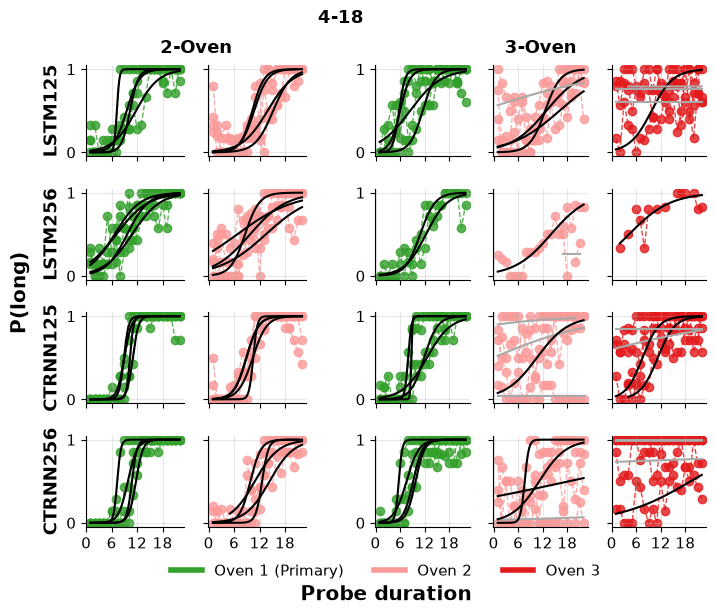

In [26]:
sigmoid_fit_df_async_4_18 = plot_noven_psychometric_curves(
    results_list=[
        delivery_counter_used_history125_async,
        delivery_counter_used_history256_async,
        delivery_counter_used_history_ctrnn125_async,
        delivery_counter_used_history_ctrnn256_async
    ],
    model_names=[
        "LSTM125",
        "LSTM256",
        "CTRNN125",
        "CTRNN256"
    ],
    anchor="4-18", fig_title="multioven_psychometric_async_4-18"
)

# Training timesteps

In [34]:
def get_training_data(results, anchors = None, figsave_filename=None, figsize=(6,6), colors = ["navy", "lightblue", "cyan"]):
    training_timesteps_rows = []
    models = list(results.keys())
    if anchors is None:
        anchors = list(results[models[0]].keys())
    
    max_training_ts = 1760000  # <-- total training timesteps
    
    fig, axes = plt.subplots(
        len(models),          # rows
        len(anchors),         # columns
        figsize=figsize,
        squeeze=False,
        sharex=True,
        constrained_layout=True
    )
    
    for row, model in enumerate(models):
    
        for col, anchor in enumerate(anchors):
    
            ax = axes[row, col]
    
            runs = sorted(results[model][anchor].keys())
            y = np.arange(len(runs))
    
            left = np.zeros(len(runs))
            values_stages = {
                    0: [],
                    1: [],
                    2: []
                } 
        
            perc_increase_stages = {
                    0: [],
                    1: [],
                    2: []
                } 
    
            for stage in range(3):
    
                widths = []
                perc_increase= []
    
                for run in runs:
    
                    values = np.array(results[model][anchor][run] + [0] * (3 - len(results[model][anchor][run]))) # append 0's for incomplete runs. not done in multianchor becuase 0's append in task performance calculation already
    
                    values_stages[stage].append(values[stage])
                        
                    learning_time = np.diff(
                        np.insert(values, 0, 0)
                    ).astype(float)
    
                    if stage >= len(learning_time):
                        widths.append(0)
                        continue
    
                    if learning_time[stage] < 0:
                        learning_time[stage] = np.nan
    
                    # Convert stage duration to percentage of total training
                    widths.append(100 * learning_time[stage] / max_training_ts)
    
                    if stage >0:
                        perc_increase.append( learning_time[stage] / learning_time[stage-1])
                    else:
                        perc_increase.append(np.nan)
    
                if stage > 0:
                    perc_increase_stages[stage] = perc_increase
                else:
                    perc_increase_stages[stage] = widths # significance test - for stage one instead of xtimes previous stage, get % timesteps needed for stage 1 
       
    

                leg_label = f"{stage+1}-Oven" 
                ax.barh(
                    y,
                    widths,
                    left=left,
                    color=colors[stage],
                    edgecolor="black",
                    linewidth=1,
                    label=leg_label if (row == 0 and col == 0) else None,
                )
    
                for run_idx, (width, perc) in enumerate(
                    zip(widths, perc_increase)
                ):
    
                    if (
                        np.isnan(perc)
                        or width <= 0
                    ):
                        continue
    
                    # Center of this bar segment
                    x_text = (
                        left[run_idx]
                        + width / 2
                    )
    
                    ax.text(
                        x_text,
                        y[run_idx],
                        f"{perc:.1f}X",
                        ha="center",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        color="black"
                    )
    
    
    
                left += np.nan_to_num(widths)
    
            ax.set_yticks(y)
    
            if col == 0:
                ax.set_yticklabels([f"Run {r}" for r in runs])
                ax.set_ylabel(model, fontweight="bold")
            else:
                ax.set_yticklabels([])
    
            if row == 0:
                ax.set_title(anchor, fontweight="bold")
    
            # if row == len(models) - 1:
            #     ax.set_xlabel("% Total Training")
    
            ax.set_xlim(0, 100)
            for run in range(len(runs)):
                training_timesteps_rows.append({"architecture":model[:-3], "memory_size":int(model[-3:]), "anchor":anchor, "run":run, 
                                               "stage0":values_stages[0][run], "stage1":values_stages[1][run], "stage2":values_stages[2][run],
                                               "stage0_pct": perc_increase_stages[0][run], "stage1-0":perc_increase_stages[1][run], "stage2-1":perc_increase_stages[2][run]})
    
            # ax.grid(axis="x", alpha=0.3)
    
    # axes[0, 0].legend(title="Curriculum stage", ncols=3, loc="lower center", )
    fig.supxlabel("% Total Training steps", y =-0.06, fontsize=13, fontweight="bold")
    plt.tight_layout()
    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    
    leg = fig.legend(
        handles,
        labels_ ,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        # ncol=len(labels_),
        ncol=len(anchors),
        frameon=False,
        columnspacing=0.5
    )
    
    if figsave_filename:
        plt.savefig(f"{figsave_filename}.pdf", bbox_inches='tight')
            
    plt.show()
    training_timestep_df = pd.DataFrame(training_timesteps_rows)
    return training_timestep_df

/tmp/ipykernel_146/2921991703.py:143: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


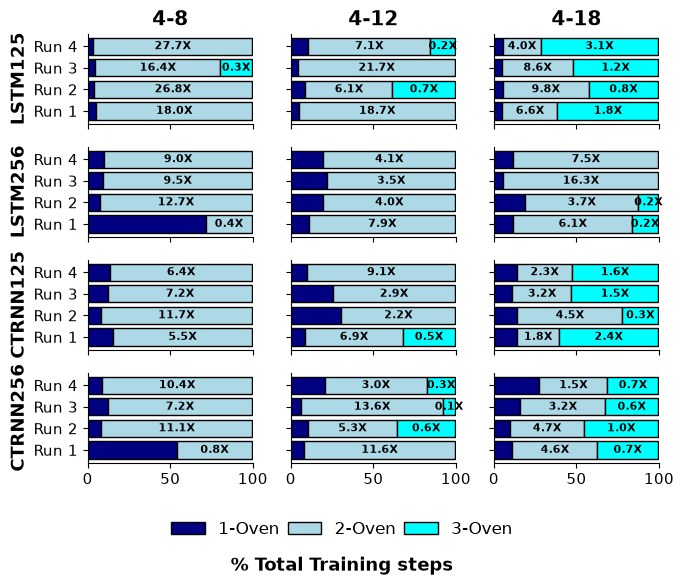

In [35]:
results = {
    "LSTM125": min_training_timesteps125_async,
    "LSTM256": min_training_timesteps256_async,
    "CTRNN125": min_training_timesteps_ctrnn125_async,
    "CTRNN256": min_training_timesteps_ctrnn256_async,
}
training_timestep_df_asyn = get_training_data(results, anchors = None, figsize=(7,5.5), figsave_filename = "Scalability_multioven_asyn_supp",colors = ["navy", "lightblue", "cyan"])

/tmp/ipykernel_146/2921991703.py:143: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


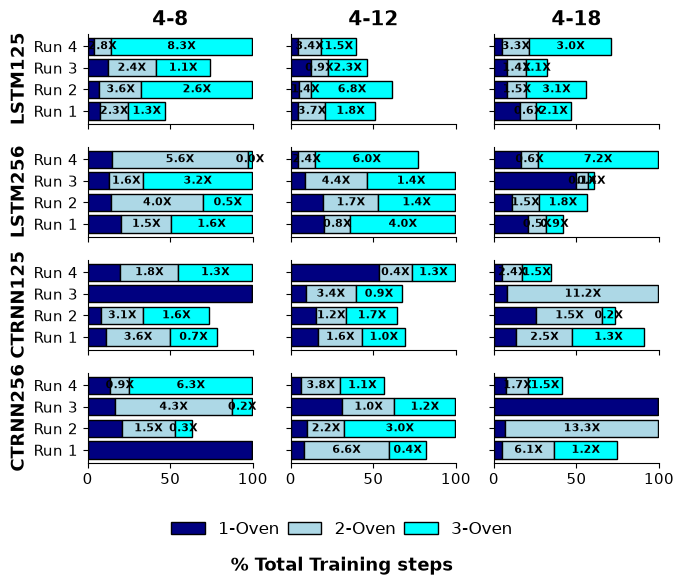

In [36]:
results = {
    "LSTM125": min_training_timesteps125_sync,
    "LSTM256": min_training_timesteps256_sync,
    "CTRNN125": min_training_timesteps_ctrnn125_sync,
    "CTRNN256": min_training_timesteps_ctrnn256_sync,
}
training_timestep_df_syn = get_training_data(results, anchors = None, figsize=(7,5.5), figsave_filename = "Scalability_multioven_syn_supp",colors = ["navy", "lightblue", "cyan"])

# async vs sync

In [144]:
# total runs converged in sync and async
print("3-oven convergence",len(training_timestep_df_syn[(training_timestep_df_syn["stage2"]<1750000) &  (training_timestep_df_syn["stage2"]>0)])/48,  len(training_timestep_df_asyn[(training_timestep_df_asyn["stage2"]<1750000) & (training_timestep_df_asyn["stage2"]>0)])/48)

print("2-oven convergence",len(training_timestep_df_syn[(training_timestep_df_syn["stage1"]<1750000) &  (training_timestep_df_syn["stage1"]>0)])/48,  len(training_timestep_df_asyn[(training_timestep_df_asyn["stage1"]<1750000) & (training_timestep_df_asyn["stage1"]>0)])/48)

3-oven convergence 0.5625 0.0
2-oven convergence 0.8958333333333334 0.4375


In [146]:
# runs converged by architecture - asyn 

print("2-oven convergence")
training_timestep_df_asyn[(training_timestep_df_asyn["stage1"]<1750000) &  (training_timestep_df_asyn["stage1"]>0)].groupby("architecture")["run"].count()


2-oven convergence


architecture
CTRNN    12
LSTM      9
Name: run, dtype: int64

In [166]:
# runs converged by architecture - syn 

print("2-oven convergence")
print(training_timestep_df_syn[(training_timestep_df_syn["stage1"]<1750000) &  (training_timestep_df_syn["stage1"]>0)].groupby("architecture")["run"].count())

print("3-oven convergence")
training_timestep_df_syn[(training_timestep_df_syn["stage2"]<1750000) &  (training_timestep_df_syn["stage2"]>0)].groupby("architecture")["run"].count()


2-oven convergence
architecture
CTRNN    19
LSTM     24
Name: run, dtype: int64
3-oven convergence


architecture
CTRNN    13
LSTM     14
Name: run, dtype: int64

In [27]:
# additional trainign timesteps needed for 2-oven case 
print("2-oven additional training",np.nanmean(training_timestep_df_syn[(training_timestep_df_syn["stage1"]<1750000) &  (training_timestep_df_syn["stage1"]>0)]["stage1-0"]),  np.nanmean(training_timestep_df_asyn[(training_timestep_df_asyn["stage1"]<1750000) &  (training_timestep_df_asyn["stage1"]>0)]["stage1-0"]))

2-oven additional training 2.369576513805604 5.863131287355186


In [ ]:
# add task performance 

# significant effect - architecture, memory size, anchor conf 

In [24]:

# significance test to check effect of env config, architecture, memory size, their interaction 
def overall_significance_test(training_timestep_df, colname, model_str=None ):
    anova_results = []

    df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
    # Make categorical variables explicit
    df["architecture"] = df["architecture"].astype("category")
    df["memory_size"] = df["memory_size"].astype("category")
    df["anchor"] = df["anchor"].astype("category")
    df = df.rename(columns={colname:"performance"})
    

    if model_str:
        model = smf.ols(model_str, data=df).fit()
    else:
        model = smf.ols(
        "performance ~ C(architecture)*C(memory_size) + C(anchor)",
        data=df).fit()

    stat, p = shapiro(model.resid)
    print("Shapiro-Wilk:", stat, p)
    print("architecture effect",df.groupby("architecture")["performance"].agg(["count","mean", "std","median"]))
    print("anchor effect",df.groupby("anchor")["performance"].agg(["count","mean", "std","median"]))

    df["residual"] = model.resid
    res_125 = df[df["memory_size"] == 125]["residual"]
    res_256 = df[df["memory_size"] == 256]["residual"]
    
    stat, p = levene(res_125, res_256, center="median")
    
    print(f"Levene: W={stat:.3f}, p={p:.3f}")

    if p < 0.05:
        print("unequal variance so using cov_type=HC3")
        if model_str:
            model = smf.ols(model_str, data=df).fit(cov_type="HC3")
            
        else:            
            model = smf.ols(
                "performance ~ C(architecture) + C(memory_size) + C(anchor)",
                data=df
            ).fit(cov_type="HC3")

       
    # print(sm.stats.anova_lm(model, typ=2))
    anova = sm.stats.anova_lm(model, typ=2)
    # print(model.t_test("C(memory_size)[T.256]"))
    print(anova)
    anova_results.append(anova)
    return anova_results        

def archlevel_significance_test(training_timestep_df, colname ):
    anova_results = []
    for arch in ["LSTM", "CTRNN"]:
        print("")
        print(arch)
        df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
        df = df[df["architecture"] == arch].copy()
        # Make categorical variables explicit
        df["architecture"] = df["architecture"].astype("category")
        df["memory_size"] = df["memory_size"].astype("category")
        df["anchor"] = df["anchor"].astype("category")
        df = df.rename(columns={colname:"performance"})
        
    
        model = smf.ols(
            "performance ~ C(memory_size) + C(anchor)",
            data=df
        ).fit()
    
        stat, p = shapiro(model.resid)
        print("Shapiro-Wilk:", stat, p)
        print("memory effect",df.groupby("memory_size")["performance"].agg(["count","mean", "std","median"]))
        print("anchor effect",df.groupby("anchor")["performance"].agg(["count","mean", "std","median"]))
    
        df["residual"] = model.resid
        res_125 = df[df["memory_size"] == 125]["residual"]
        res_256 = df[df["memory_size"] == 256]["residual"]
        
        stat, p = levene(res_125, res_256, center="median")
        
        print(f"Levene: W={stat:.3f}, p={p:.3f}")
    
        if p < 0.05:
            print("unequal variance so using cov_type=HC3")
            model = smf.ols(
            "performance ~ C(memory_size) + C(anchor)",
                data=df
            ).fit(cov_type="HC3")
           
        # print(sm.stats.anova_lm(model, typ=2))
        anova = sm.stats.anova_lm(model, typ=2)
        # print(model.t_test("C(memory_size)[T.256]"))
        print(anova)
        anova_results.append(anova)
    return anova_results
    


In [25]:
# if normality is violated in the above old tests and anchor does not have significant effect in the overall test with n>25 
# use the following test to justify combining models within architecture 
def memory_within_arch(training_timestep_df, colname):

    # anova_results = []
    for arch in ["LSTM", "CTRNN"]:
        print("")
        print(arch)
        df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
        df = df[df["architecture"] == arch].copy()
        x1 = df[df["memory_size"]==125][colname]
        n_x = len(x1)
        y1 = df[df["memory_size"]==256][colname]
        n_y = len(y1)
        # get 
        

            # --- Normality check ---
        sh_x_p = shapiro(x1)[1] if n_x >= 3 else np.nan
        sh_y_p = shapiro(y1)[1] if n_y >= 3 else np.nan
        normal = (not np.isnan(sh_x_p)) and (not np.isnan(sh_y_p)) and (sh_x_p > 0.05) and (sh_y_p > 0.05)
    
        # --- Homogeneity of variance check ---
        lev_p = levene(x1, y1)[1] if n_x >= 2 and n_y >= 2 else np.nan
        equal_var = (not np.isnan(lev_p)) and (lev_p > 0.05)
    
        if normal:
            stat, p = ttest_ind(x1, y1, equal_var=equal_var)
            test_used = "Welch's t-test" if not equal_var else "Student's t-test"
        else:
            # Fallback: Mann-Whitney U test (non-parametric, no normality assumption)
            try:
                stat, p = mannwhitneyu(x1, y1, alternative="two-sided")
                test_used = "Mann-Whitney U"
            except ValueError:
                stat, p = np.nan, np.nan
                test_used = "Mann-Whitney U (failed, insufficient data)"

        print(test_used, "normality", normal, "equal variance", equal_var, stat, p)

In [26]:
def architecture_level_independent_test(significance_test_df, colname, first_arch=None):
    lstm, ctrnn = None, None
    for grp, data in significance_test_df.groupby("architecture"):
        if grp == "CTRNN":
            ctrnn = data[colname].dropna()
        if grp == "LSTM":
            lstm = data[colname].dropna()
    
    if first_arch == "ctrnn":
        arch_comparison_ordered = [ctrnn,lstm]
    elif first_arch == "lstm":
        arch_comparison_ordered = [lstm,ctrnn]
    else:
        raise ValueError("no arch order specified. provide an arch order for alternative = greater test")

        
    # --- Normality check (per group) ---
    sh_lstm_p = shapiro(lstm)[1] if len(lstm) >= 3 else np.nan
    sh_ctrnn_p = shapiro(ctrnn)[1] if len(ctrnn) >= 3 else np.nan
    normal = (not np.isnan(sh_lstm_p)) and (not np.isnan(sh_ctrnn_p)) and (sh_lstm_p > 0.05) and (sh_ctrnn_p > 0.05)
    print(f"Shapiro-Wilk: LSTM p={sh_lstm_p:.4f}, CTRNN p={sh_ctrnn_p:.4f}, normal={normal}")
    
    # --- Homogeneity of variance check ---
    lev_stat, lev_p = levene(lstm, ctrnn, center="median")
    equal_var = lev_p > 0.05
    print(f"Levene: stat={lev_stat:.3f}, p={lev_p:.4f}, equal_var={equal_var}")
    
    # --- Choose test based on assumptions ---
    if normal:
        t, p = ttest_ind(ctrnn, lstm, equal_var=equal_var, alternative="greater")
        test_used = "Welch's t-test" if not equal_var else "Student's t-test"
    else:
        # Fallback: Mann-Whitney U (non-parametric, independent samples)
        t, p = mannwhitneyu(ctrnn, lstm, alternative="greater")
        test_used = "Mann-Whitney U"
    
    print(f"Test used: {test_used}, stat={t:.3f}, p={p:.4f}")

In [27]:
# test if cl_ratio per model or architecture is more than 1x 
def cl_ratio_vs_1x(vals, alternative="greater"):
    vals = vals.dropna()
    n = len(vals)
    sh_p = shapiro(vals)[1] if n >= 3 else np.nan
    normal = (not np.isnan(sh_p)) and (sh_p > 0.05)

    if normal:
        stat, p = ttest_1samp(vals, popmean=1, alternative=alternative)
        test_used = "t-test"
    else:
        try:
            stat, p = wilcoxon(vals - 1, alternative=alternative)
            test_used = "Wilcoxon"
        except ValueError:
            stat, p = np.nan, np.nan
            test_used = "Wilcoxon (failed, likely all-zero diffs)"

    return n, sh_p, normal, test_used, stat, p

# cl stage 0 - async

In [43]:
training_timestep_df_asyn

,architecture,memory_size,anchor,run,stage0,stage1,stage2,stage0_pct,stage1-0,stage2-1
0,LSTM,125,4-8,0,92000,1750000,0,5.227273,18.021739,NaN
1,LSTM,125,4-8,1,63000,1750000,0,3.579545,26.777778,NaN
2,LSTM,125,4-8,2,81000,1411000,1750000,4.602273,16.419753,0.254887
3,LSTM,125,4-8,3,61000,1750000,0,3.465909,27.688525,NaN
4,LSTM,125,4-12,0,89000,1750000,0,5.056818,18.662921,NaN
5,LSTM,125,4-12,1,152000,1084000,1750000,8.636364,6.131579,0.714592
6,LSTM,125,4-12,2,77000,1750000,0,4.375000,21.727273,NaN
7,LSTM,125,4-12,3,183000,1486000,1750000,10.397727,7.120219,0.202609
8,LSTM,125,4-18,0,89000,677000,1750000,5.056818,6.606742,1.824830
9,LSTM,125,4-18,1,93000,1009000,1750000,5.284091,9.849462,0.808952


In [53]:
# filter cases of non-convergence 
significance_test_df = training_timestep_df_asyn[(training_timestep_df_asyn["stage0"] < 1750000) & (training_timestep_df_asyn["stage0"] >0)].copy()
colname = "stage0_pct"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count       mean        std     median
architecture memory_size                                        
CTRNN        125             12  14.734848   6.736700  13.721591
             256             12  15.999053  13.421243  10.710227
LSTM         125             12   5.525568   2.011181   5.056818
             256             12  18.210227  17.603811  11.789773
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.709830890587816 1.988034751154288e-08
architecture effect               count       mean        std     median
architecture                                        
CTRNN            24  15.366951  10.405331  12.130682
LSTM             24  11.867898  13.860693   7.954545
anchor effect         count       mean        std     median
anchor                            

In [47]:
# normality violoted - but anchor no significant effect in overall analysis with n>25
significance_test_df = training_timestep_df_asyn[(training_timestep_df_asyn["stage0"] < 1750000) & (training_timestep_df_asyn["stage0"] >0)].copy()
colname = "stage0_pct"
memory_within_arch(significance_test_df, colname)


LSTM
Mann-Whitney U normality False equal variance True 6.0 0.00015528191705419366

CTRNN
Mann-Whitney U normality False equal variance True 84.0 0.5067205148778584


In [54]:
# is ctrnn significantly greater than lstm 

# filter for convergence 
significance_test_df = training_timestep_df_asyn[(training_timestep_df_asyn["stage0"] < 1750000) & (training_timestep_df_asyn["stage0"] >0)].copy()
colname = "stage0_pct"


architecture_level_independent_test(significance_test_df, colname, first_arch="ctrnn")

Shapiro-Wilk: LSTM p=0.0000, CTRNN p=0.0000, normal=False
Levene: stat=0.062, p=0.8049, equal_var=True
Test used: Mann-Whitney U, stat=415.000, p=0.0045


# stage 1-0 - async

In [55]:
# filter cases of non-convergence 
significance_test_df = training_timestep_df_asyn[(training_timestep_df_asyn["stage1"] < 1750000) & (training_timestep_df_asyn["stage1"] >0)].copy()
colname = "stage1-0"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

print("-----------------------within architecture in case of non-normality------------")
memory_within_arch(significance_test_df, colname)
print("--------------------------------------------------------------------")


----------------------------------------------------------------------
Total convergence                           count      mean       std    median
architecture memory_size                                     
CTRNN        125              5  3.743321  2.036809  3.192893
             256              7  5.135251  3.940723  4.550505
LSTM         125              7  8.386396  3.992131  7.120219
             256              2  4.878811  1.673989  4.878811
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.9066139574589477 0.04709819630462872
architecture effect               count      mean       std    median
architecture                                     
CTRNN            12  4.555280  3.239264  3.855529
LSTM              9  7.606933  3.833457  6.606742
anchor effect         count       mean       std     median
anchor                                       
4-12        6   7.01

In [58]:
# filter cases of non-convergence and anchor 4-8 whcih has only 1 sample
significance_test_df = training_timestep_df_asyn[(training_timestep_df_asyn["stage1"] < 1750000) 
    & (training_timestep_df_asyn["stage1"] >0) & (training_timestep_df_asyn["anchor"]!="4-8")].copy()
colname = "stage1-0"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

print("-----------------------within architecture in case of non-normality------------")
memory_within_arch(significance_test_df, colname)
print("--------------------------------------------------------------------")


----------------------------------------------------------------------
Total convergence                           count      mean       std    median
architecture memory_size                                     
CTRNN        125              5  3.743321  2.036809  3.192893
             256              7  5.135251  3.940723  4.550505
LSTM         125              6  7.047504  2.016533  6.863480
             256              2  4.878811  1.673989  4.878811
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.9071752544821651 0.05632047645307174
architecture effect               count     mean       std    median
architecture                                    
CTRNN            12  4.55528  3.239264  3.855529
LSTM              8  6.50533  2.076712  6.369160
anchor effect         count      mean       std    median
anchor                                     
4-12        6  7.014974  3.5

In [59]:
# is lstm higher than ctrnn ?
# filter for convergence 
significance_test_df = training_timestep_df_asyn[(training_timestep_df_asyn["stage1"] < 1750000) 
    & (training_timestep_df_asyn["stage1"] >0) & (training_timestep_df_asyn["anchor"]!="4-8")].copy()
colname = "stage1-0"


architecture_level_independent_test(significance_test_df, colname, first_arch="lstm")

Shapiro-Wilk: LSTM p=0.7661, CTRNN p=0.0046, normal=False
Levene: stat=0.275, p=0.6066, equal_var=True
Test used: Mann-Whitney U, stat=21.000, p=0.9843


In [60]:

# architecture level analysis across memory size and anchors - 
#  mention the results with caveats of signifcant effect of memory or anchor or interaction terms in case any 


# Is CL-efficiency ratio >1x ?

# filter for convergence 
significance_test_df = training_timestep_df_asyn[(training_timestep_df_asyn["stage1"] < 1750000) 
    & (training_timestep_df_asyn["stage1"] >0) & (training_timestep_df_asyn["anchor"]!="4-8")].copy()
colname = "stage1-0"

# --- Architecture-level (primary result, given memory sizes pooled) ---
print("=== Architecture level ===")
for grp, data in significance_test_df.groupby("architecture"):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

# --- Per-model (optional, supplementary) ---
print("\n=== Per architecture-memory_size (supplementary) ===")
for grp, data in significance_test_df.groupby(["architecture", "memory_size"]):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

=== Architecture level ===
CTRNN: n=12, shapiro_p=0.005, normal=False, test=Wilcoxon, stat=78.000, p=0.0002
LSTM: n=8, shapiro_p=0.766, normal=True, test=t-test, stat=7.498, p=0.0001

=== Per architecture-memory_size (supplementary) ===
('CTRNN', 125): n=5, shapiro_p=0.524, normal=True, test=t-test, stat=3.012, p=0.0197
('CTRNN', 256): n=7, shapiro_p=0.017, normal=False, test=Wilcoxon, stat=28.000, p=0.0078
('LSTM', 125): n=6, shapiro_p=0.972, normal=True, test=t-test, stat=7.346, p=0.0004
('LSTM', 256): n=2, shapiro_p=nan, normal=False, test=Wilcoxon, stat=3.000, p=0.2500


# stage 1-0 Sync

In [61]:
# filter cases of non-convergence 
significance_test_df = training_timestep_df_syn[(training_timestep_df_syn["stage1"] < 1750000) & (training_timestep_df_syn["stage1"] >0)].copy()
colname = "stage1-0"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

print("-----------------------within architecture in case of non-normality------------")
memory_within_arch(significance_test_df, colname)
print("--------------------------------------------------------------------")


----------------------------------------------------------------------
Total convergence                           count      mean       std    median
architecture memory_size                                     
CTRNN        125             10  2.160389  1.031766  2.105840
             256              9  3.126195  2.173609  2.196629
LSTM         125             12  2.273609  1.081257  2.384324
             256             12  2.072404  1.733490  1.571161
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.9520620586571191 0.07091054915651382
architecture effect               count      mean       std    median
architecture                                     
CTRNN            19  2.617876  1.696334  2.196629
LSTM             24  2.173006  1.416641  1.642581
anchor effect         count      mean       std    median
anchor                                     
4-12       16  2.425956 

In [62]:
# is ctrnn higher than lstm ?
# filter for convergence 
significance_test_df = training_timestep_df_syn[(training_timestep_df_syn["stage1"] < 1750000) & (training_timestep_df_syn["stage1"] >0)].copy()
colname = "stage1-0"


architecture_level_independent_test(significance_test_df, colname, first_arch="ctrnn")

Shapiro-Wilk: LSTM p=0.1766, CTRNN p=0.0629, normal=True
Levene: stat=0.193, p=0.6629, equal_var=True
Test used: Student's t-test, stat=0.937, p=0.1771


In [63]:
significance_test_df = training_timestep_df_syn[(training_timestep_df_syn["stage1"] < 1750000) & (training_timestep_df_syn["stage1"] >0)].copy()
colname = "stage1-0"

# architecture level analysis across memory size and anchors - 
#  mention the results with caveats of signifcant effect of memory or anchor or interaction terms in case any 


# Is CL-efficiency ratio >1x ?


# --- Architecture-level (primary result, given memory sizes pooled) ---
print("=== Architecture level ===")
for grp, data in significance_test_df.groupby("architecture"):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

# --- Per-model (optional, supplementary) ---
print("\n=== Per architecture-memory_size (supplementary) ===")
for grp, data in significance_test_df.groupby(["architecture", "memory_size"]):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

=== Architecture level ===
CTRNN: n=19, shapiro_p=0.063, normal=True, test=t-test, stat=4.157, p=0.0003
LSTM: n=24, shapiro_p=0.177, normal=True, test=t-test, stat=4.056, p=0.0002

=== Per architecture-memory_size (supplementary) ===
('CTRNN', 125): n=10, shapiro_p=0.813, normal=True, test=t-test, stat=3.556, p=0.0031
('CTRNN', 256): n=9, shapiro_p=0.181, normal=True, test=t-test, stat=2.935, p=0.0094
('LSTM', 125): n=12, shapiro_p=0.269, normal=True, test=t-test, stat=4.080, p=0.0009
('LSTM', 256): n=12, shapiro_p=0.076, normal=True, test=t-test, stat=2.143, p=0.0277


# stage 2-1 - synch

In [ ]:
# filter cases of non-convergence 
significance_test_df = training_timestep_df_syn[(training_timestep_df_syn["stage1"] < 1750000) & (training_timestep_df_syn["stage1"] >0)].copy()
colname = "stage1-0"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

print("-----------------------within architecture in case of non-normality------------")
memory_within_arch(significance_test_df, colname)
print("--------------------------------------------------------------------")


In [ ]:
# total runs with successful soup delivery task for 3 oven (4-18). /24 runs 
# CTRNN 8/8
# LSTM 6/8

# Task performance

failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery


/tmp/ipykernel_145/833464385.py:175: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(logistic, td_keys_fit, percentages_fit, p0=initial_params,)
/tmp/ipykernel_145/833464385.py:348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


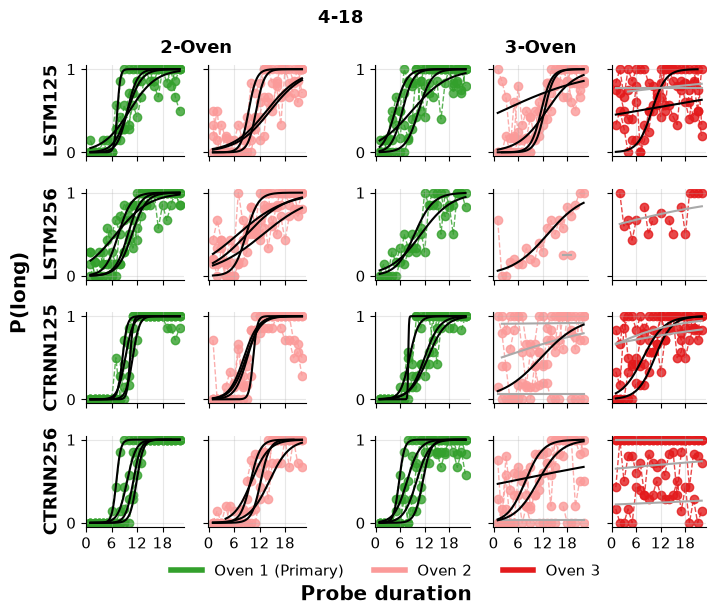

failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed soup delivery
failed soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery


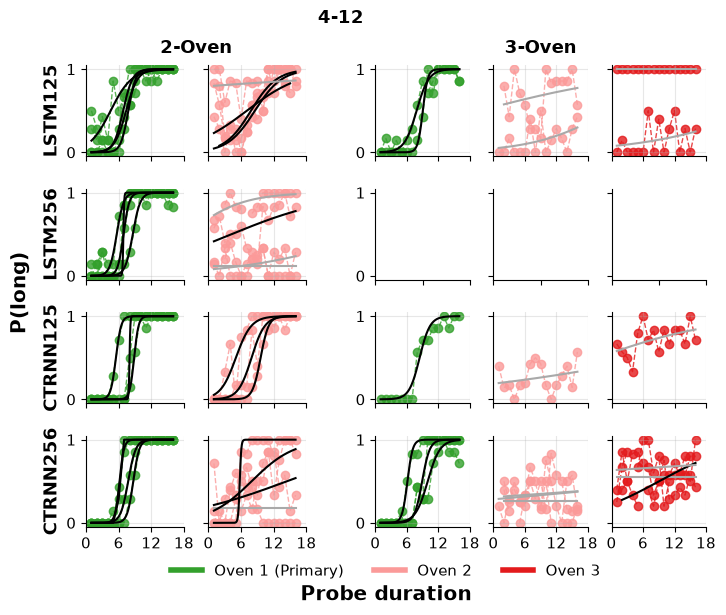

failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed soup delivery
failed soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery


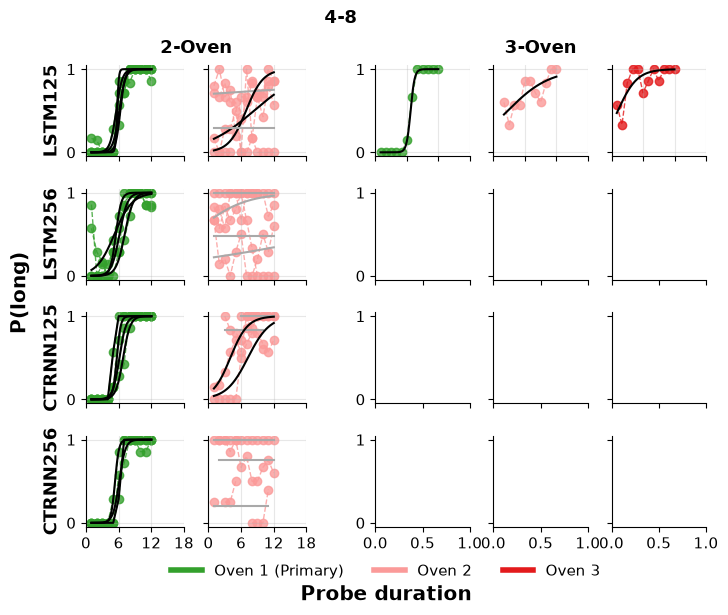

In [27]:
# async -
# 4-18
sigmoid_fit_df_async_4_18 = plot_noven_psychometric_curves(
    results_list=[
        delivery_counter_used_history125_async,
        delivery_counter_used_history256_async,
        delivery_counter_used_history_ctrnn125_async,
        delivery_counter_used_history_ctrnn256_async
    ],
    model_names=[
        "LSTM125",
        "LSTM256",
        "CTRNN125",
        "CTRNN256"
    ],
    anchor="4-18", fig_title="multioven_psychometric_async_4-18"
)

# 4-12
sigmoid_fit_df_async_4_12 = plot_noven_psychometric_curves(
    results_list=[
        delivery_counter_used_history125_async,
        delivery_counter_used_history256_async,
        delivery_counter_used_history_ctrnn125_async,
        delivery_counter_used_history_ctrnn256_async
    ],
    model_names=[
        "LSTM125",
        "LSTM256",
        "CTRNN125",
        "CTRNN256"
    ],
    anchor="4-12", fig_title="multioven_psychometric_async_4-12"
)

# 4-8
sigmoid_fit_df_async_4_8 = plot_noven_psychometric_curves(
    results_list=[
        delivery_counter_used_history125_async,
        delivery_counter_used_history256_async,
        delivery_counter_used_history_ctrnn125_async,
        delivery_counter_used_history_ctrnn256_async
    ],
    model_names=[
        "LSTM125",
        "LSTM256",
        "CTRNN125",
        "CTRNN256"
    ],
    anchor="4-8", fig_title="multioven_psychometric_async_4-8"
)
# get successful runs
sigmoid_fit_df_async_4_18["bp_cat"] = sigmoid_fit_df_async_4_18.apply(lambda x: "failed timing" if x["bp"] == -100 else "failed soup delivery" if pd.isna(x["bp"]) else "success", axis=1)
sigmoid_fit_df_async_4_12["bp_cat"] = sigmoid_fit_df_async_4_12.apply(lambda x: "failed timing" if x["bp"] == -100 else "failed soup delivery" if pd.isna(x["bp"]) else "success", axis=1)
sigmoid_fit_df_async_4_8["bp_cat"] = sigmoid_fit_df_async_4_8.apply(lambda x: "failed timing" if x["bp"] == -100 else "failed soup delivery" if pd.isna(x["bp"]) else "success", axis=1)

In [96]:
sigmoid_fit_df_async_4_18

,architecture,mem_size,anchors,n_oven_setting,oven_number,run,x0,k,bp,t25,t75,jnd,bp_cat
0,LSTM,125,4-18,3,0,1-1750000,5.763285e+00,7.292727e-01,5.763,4.962,6.564,0.801,success
1,LSTM,125,4-18,3,1,1-1750000,1.288500e+01,4.301212e+00,12.885,8.160,17.610,4.725,success
2,LSTM,125,4-18,3,2,1-1750000,-2.038660e+08,1.793821e+08,-100.000,-100.000,-100.000,-100.000,failed timing
3,LSTM,125,4-18,2,0,1-677000,7.217621e+00,3.056479e-01,7.218,6.882,7.553,0.336,success
4,LSTM,125,4-18,2,1,1-677000,1.387629e+01,2.976833e+00,13.876,10.606,17.147,3.270,success
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,CTRNN,256,4-18,2,0,4-1210000,1.173250e+01,8.315293e-01,11.733,10.819,12.646,0.914,success
70,CTRNN,256,4-18,2,1,4-1210000,1.259222e+01,7.476413e-01,12.592,11.771,13.414,0.821,success
71,CTRNN,256,4-18,3,0,4-1750000,9.200191e+00,1.155189e+00,9.200,7.931,10.469,1.269,success
72,CTRNN,256,4-18,3,1,4-1750000,7.593982e+00,5.062076e-01,7.594,7.038,8.150,0.556,success


In [39]:
# model-level
# total runs with successful timing task. \total successful soup deliveires 
sigmoid_fit_df_async_4_18[(sigmoid_fit_df_async_4_18["n_oven_setting"]==3) & (sigmoid_fit_df_async_4_18["bp_cat"]=="success")].groupby(["architecture","memory_size"])["bp"].describe()

count       mean       std    min       25%     50%  \
architecture memory_size                                                        
CTRNN        125            8.0   9.076375  3.581162  1.301   8.24050   9.799   
             256            6.0   8.534833  2.212257  5.066   7.43175   8.903   
LSTM         125            8.0  10.236875  3.845927  4.790   7.61125  10.530   
             256            3.0  11.049000  1.798345  9.200  10.17750  11.155   

                               75%     max  
architecture memory_size                    
CTRNN        125          11.40925  12.393  
             256          10.02250  11.000  
LSTM         125          13.07050  15.662  
             256          11.97350  12.792

In [30]:
# architecture-level
# total runs with successful timing task. \total successful soup deliveires 
print("2 oven")
print(sigmoid_fit_df_async_4_18[(sigmoid_fit_df_async_4_18["n_oven_setting"]==2) & (sigmoid_fit_df_async_4_18["bp_cat"]=="success")].groupby(["architecture"])["bp"].count())
print(sigmoid_fit_df_async_4_12[(sigmoid_fit_df_async_4_12["n_oven_setting"]==2) & (sigmoid_fit_df_async_4_12["bp_cat"]=="success")].groupby(["architecture"])["bp"].count())
print(sigmoid_fit_df_async_4_8[(sigmoid_fit_df_async_4_8["n_oven_setting"]==2) & (sigmoid_fit_df_async_4_8["bp_cat"]=="success")].groupby(["architecture"])["bp"].count())

print("3 oven")
print(sigmoid_fit_df_async_4_18[(sigmoid_fit_df_async_4_18["n_oven_setting"]==3) & (sigmoid_fit_df_async_4_18["bp_cat"]=="success")].groupby(["architecture"])["bp"].count())
print(sigmoid_fit_df_async_4_12[(sigmoid_fit_df_async_4_12["n_oven_setting"]==3) & (sigmoid_fit_df_async_4_12["bp_cat"]=="success")].groupby(["architecture"])["bp"].count())
print(sigmoid_fit_df_async_4_8[(sigmoid_fit_df_async_4_8["n_oven_setting"]==3) & (sigmoid_fit_df_async_4_8["bp_cat"]=="success")].groupby(["architecture"])["bp"].count())

2 oven
architecture
CTRNN    16
LSTM     16
Name: bp, dtype: int64
architecture
CTRNN    13
LSTM     12
Name: bp, dtype: int64
architecture
CTRNN     9
LSTM     10
Name: bp, dtype: int64
3 oven
architecture
CTRNN    14
LSTM     13
Name: bp, dtype: int64
architecture
CTRNN    5
LSTM     2
Name: bp, dtype: int64
architecture
LSTM    3
Name: bp, dtype: int64


In [42]:
sigmoid_fit_df_async_4_18[(sigmoid_fit_df_async_4_18["n_oven_setting"]==3) & (sigmoid_fit_df_async_4_18["bp_cat"]=="success")]["bp"].describe()

count    25.000000
mean      9.554480
std       3.180294
min       1.301000
25%       8.005000
50%       9.976000
75%      11.674000
max      15.662000
Name: bp, dtype: float64

failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery


/tmp/ipykernel_145/833464385.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-(x - x0) / k))
/tmp/ipykernel_145/833464385.py:175: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(logistic, td_keys_fit, percentages_fit, p0=initial_params,)
/tmp/ipykernel_145/833464385.py:348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


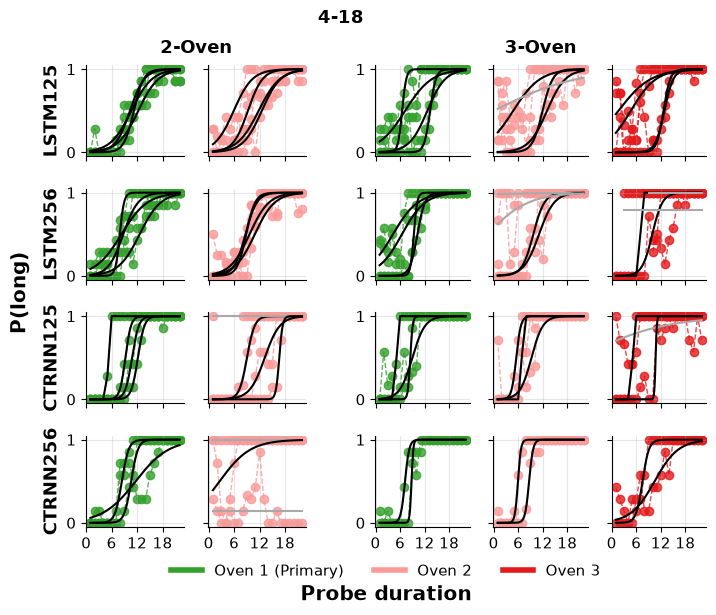

failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task: could not fit a sigmoid or calculate bp manually
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task: could not fit a sigmoid or calculate bp manually


/tmp/ipykernel_145/833464385.py:198: RuntimeWarning: Mean of empty slice
  elif np.nanmean(percentages[0:short]) <=0.2 and np.nanmean(percentages[long:]) >=0.8: # strict , FN - good psychometric (mostly step) that does not fit logistic


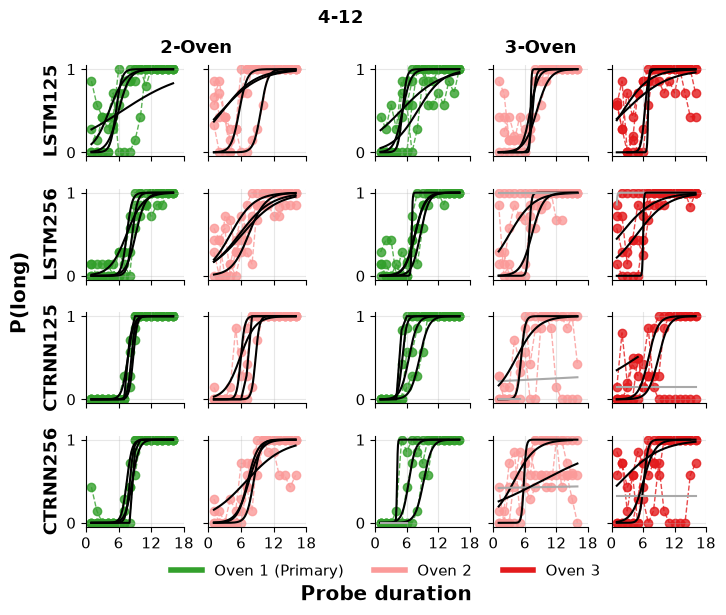

failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task but successful soup delivery
failed timing task: could not fit a sigmoid or calculate bp manually
failed timing task but successful soup delivery


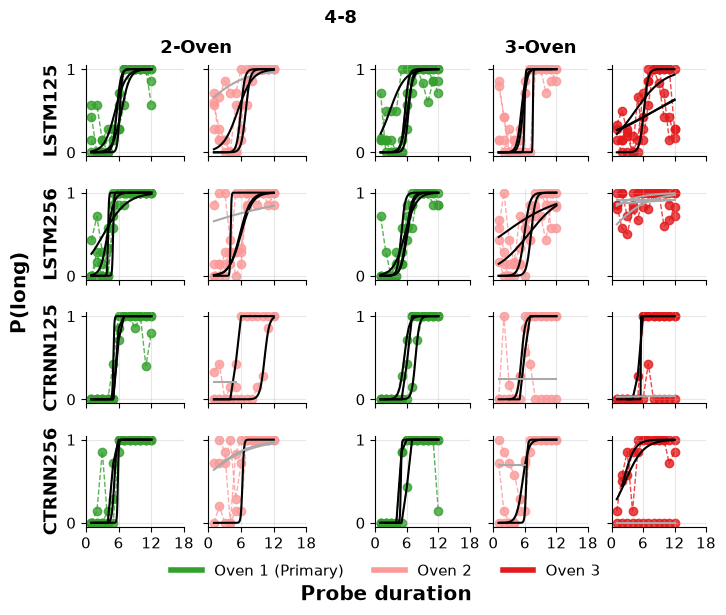

In [43]:
# sync -
# 4-18
sigmoid_fit_df_sync_4_18 = plot_noven_psychometric_curves(
    results_list=[
        delivery_counter_used_history125_sync,
        delivery_counter_used_history256_sync,
        delivery_counter_used_history_ctrnn125_sync,
        delivery_counter_used_history_ctrnn256_sync
    ],
    model_names=[
        "LSTM125",
        "LSTM256",
        "CTRNN125",
        "CTRNN256"
    ],
    anchor="4-18", fig_title="multioven_psychometric_sync_4-18"
)

# 4-12
sigmoid_fit_df_sync_4_12 = plot_noven_psychometric_curves(
    results_list=[
        delivery_counter_used_history125_sync,
        delivery_counter_used_history256_sync,
        delivery_counter_used_history_ctrnn125_sync,
        delivery_counter_used_history_ctrnn256_sync
    ],
    model_names=[
        "LSTM125",
        "LSTM256",
        "CTRNN125",
        "CTRNN256"
    ],
    anchor="4-12", fig_title="multioven_psychometric_sync_4-12"
)

# 4-8
sigmoid_fit_df_sync_4_8 = plot_noven_psychometric_curves(
    results_list=[
        delivery_counter_used_history125_sync,
        delivery_counter_used_history256_sync,
        delivery_counter_used_history_ctrnn125_sync,
        delivery_counter_used_history_ctrnn256_sync
    ],
    model_names=[
        "LSTM125",
        "LSTM256",
        "CTRNN125",
        "CTRNN256"
    ],
    anchor="4-8", fig_title="multioven_psychometric_sync_4-8"
)

# get successful runs
sigmoid_fit_df_sync_4_18["bp_cat"] = sigmoid_fit_df_sync_4_18.apply(lambda x: "failed timing" if x["bp"] == -100 else "failed soup delivery" if pd.isna(x["bp"]) else "success", axis=1)
sigmoid_fit_df_sync_4_12["bp_cat"] = sigmoid_fit_df_sync_4_12.apply(lambda x: "failed timing" if x["bp"] == -100 else "failed soup delivery" if pd.isna(x["bp"]) else "success", axis=1)
sigmoid_fit_df_sync_4_8["bp_cat"] = sigmoid_fit_df_sync_4_8.apply(lambda x: "failed timing" if x["bp"] == -100 else "failed soup delivery" if pd.isna(x["bp"]) else "success", axis=1)

In [89]:
# model-level
# total runs with successful timing task. \total successful soup deliveires 
sigmoid_fit_df_sync_4_18[(sigmoid_fit_df_sync_4_18["n_oven_setting"]==2) & (sigmoid_fit_df_sync_4_18["bp_cat"]=="success")].groupby(["architecture","mem_size"])["bp"].describe()

count       mean       std    min       25%      50%  \
architecture mem_size                                                         
CTRNN        125         8.0  10.492875  2.144027  5.910  10.04975  10.9335   
             256         4.0   8.311500  4.052037  2.585   6.94625   9.5000   
LSTM         125         8.0  10.492875  2.144027  5.910  10.04975  10.9335   
             256         8.0   9.451500  1.561684  7.930   8.58200   8.7900   

                            75%     max  
architecture mem_size                    
CTRNN        125       11.90775  12.534  
             256       10.86525  11.661  
LSTM         125       11.90775  12.534  
             256        9.94850  12.598

In [44]:
# total in sych variant
sigmoid_fit_df_sync_4_18[(sigmoid_fit_df_sync_4_18["n_oven_setting"]==2) & (sigmoid_fit_df_sync_4_18["bp_cat"]=="success")]["bp"].describe()

count    27.000000
mean      9.941074
std       2.813410
min       2.585000
25%       8.705000
50%      10.316000
75%      11.722000
max      16.640000
Name: bp, dtype: float64

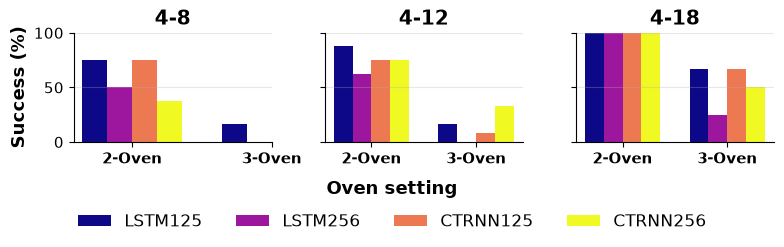

In [50]:
# plot % success
dfs = [
    sigmoid_fit_df_async_4_8,
    sigmoid_fit_df_async_4_12,
    sigmoid_fit_df_async_4_18,
]

# dfs = [
#     sigmoid_fit_df_sync_4_8,
#     sigmoid_fit_df_sync_4_12,
#     sigmoid_fit_df_sync_4_18,
# ]

models = [
    ("LSTM", "125"),
    ("LSTM", "256"),
    ("CTRNN", "125"),
    ("CTRNN", "256"),
]

cmap = plt.cm.plasma
colors = cmap(np.linspace(0, 1, len(models)))

anchors = ["4-8", "4-12", "4-18"]



fig, axes = plt.subplots(1, 3, figsize=(8, 2.3), sharey=True)

for ax, df, anchor in zip(axes, dfs, anchors):

    # Calculate success percentage for each oven setting and model
    df = df.dropna()
    summary = (
        df.groupby(["n_oven_setting", "architecture", "memory_size"])["bp_cat"]
        .agg(
            n_success=lambda x: (x == "success").sum()
        )
        .reset_index()
    )

    summary["success_pct"] = (
        100 * summary["n_success"] / (summary["n_oven_setting"]*4)
    )

    # Bar positions
    x = np.arange(2)  # 2-oven, 3-oven
    width = 0.18

    for i, (architecture, mem_size) in enumerate(models):

        model_data = summary[
            (summary["architecture"] == architecture) &
            (summary["memory_size"] == mem_size)
        ].set_index("n_oven_setting")

        values = [
            model_data["success_pct"].get(2, np.nan),
            model_data["success_pct"].get(3, np.nan),
        ]

        offset = (i - 1.5) * width

        ax.bar(
            x + offset,
            values,
            width,
            label=f"{architecture.upper()}{mem_size}",
            color=colors[i]
        )

    ax.set_title(f"{anchor}",fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["2-Oven", "3-Oven"], fontweight="bold")
    # ax.set_xlabel("Oven setting")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Success (%)", fontweight="bold")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.1),
    frameon=False
)
fig.supxlabel("Oven setting", y=0.1,fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("multioven_syn_performance.pdf", bbox_inches='tight')
plt.savefig("multioven_asyn_performance.pdf", bbox_inches='tight')
plt.show()

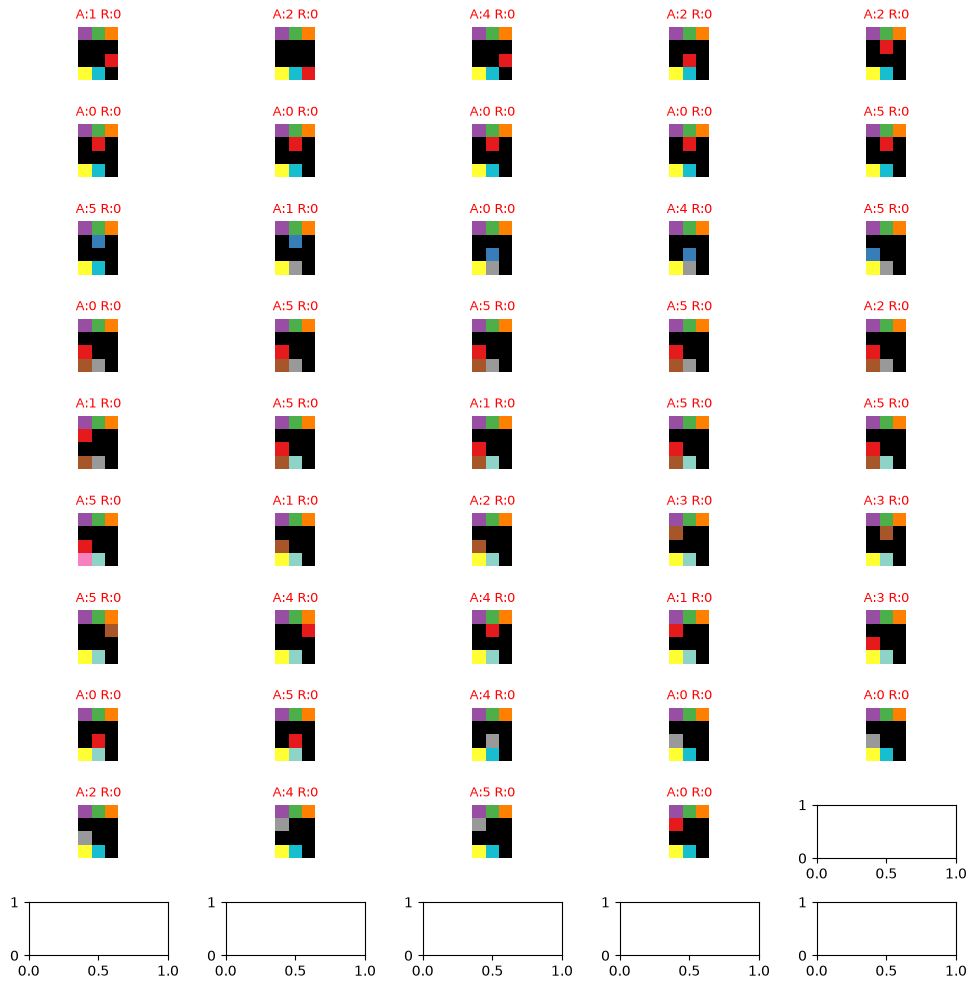

In [22]:
td = 11
anchor = "4-8"
seed_i = 5
plot_traj(observation_history125_2async[anchor]['1-950000'][td][seed_i], action_history125_2async[anchor]['1-950000'][td][seed_i], 
          reward_history125_2async[anchor]['1-950000'][td][seed_i], n_rows=10, figsize=(10,10))

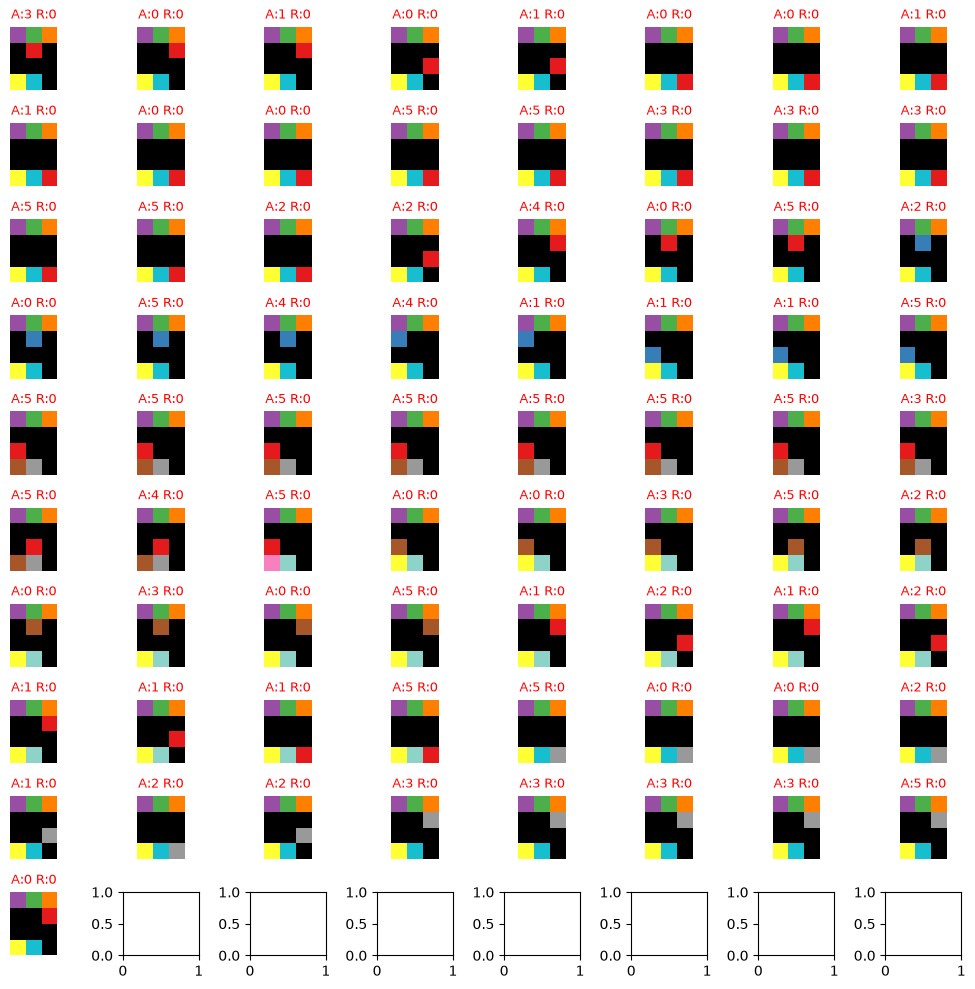

In [30]:
td = 11
anchor = "4-8"
seed_i = 1
plot_traj(observation_history125_2sync[anchor]['1-950000'][td][seed_i], action_history125_2sync[anchor]['1-950000'][td][seed_i], 
          reward_history125_2sync[anchor]['1-950000'][td][seed_i], n_rows=10, figsize=(10,10))